**SAIRUS: LLM-BASED CLASSIFICATION AND SYNTHETIC RELATIONSHIP GENERATION**

This notebook evaluates the performance of the LEXI LLM on a binary classification task. Using this LLM, we established a strong baseline for comparison with the classic approach used in the SAIRUS project.
Subsequently, we developed a method to generate new synthetic relationships between synthetic users.

In [ ]:
!pip install transformers bitsandbytes torch tqdm
!pip install emoji
!pip install cleantext
!pip install -U bitsandbytes

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 76.1/76.1 MB 7.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 363.4/363.4 MB 4.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 13.8/13.8 MB 31.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 24.6/24.6 MB 23.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 883.7/883.7 kB 15.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 664.8/664.8 MB 2.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 211.5/211.5 MB 4.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 56.3/56.3 MB 6.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 127.9/127.9 MB 4.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 207.5/207.5 MB 5.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 21.1/21.1 MB 55.4 MB/s eta 0:00:00
  Attempting uninstall: nvidia-nvjitlink-cu12
    Found existing installation: nvidia-nvjitlink-cu12 12.5.82
    Uninstalling 

In [ ]:
from transformers import AutoTokenizer, AutoModelForCausalLM, BitsAndBytesConfig
from transformers import StoppingCriteria, StoppingCriteriaList
from tqdm import tqdm

import random
import math
import torch
import pandas as pd
import json
import os
from cleantext import clean
import emoji
import numpy as np
from sklearn.metrics import confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import f1_score, accuracy_score, precision_score, recall_score
import matplotlib.pyplot as plt
from scipy.sparse import lil_matrix
import pickle
import re

In [ ]:
def load_model_and_tokenizer():
    """
    Loads a quantized Llama-3.1-8B model and its tokenizer.

    - Uses 4-bit NF4 quantization for reduced memory usage.
    - Loads model on available device using `device_map="auto"`.

    Returns:
        model: The quantized language model.
        tokenizer: The corresponding tokenizer.
    """

    # Define quantization configuration for 4-bit inference
    quantization_config = BitsAndBytesConfig(
        load_in_8bit=False,  # Do not use 8-bit quantization
        load_in_4bit=True,   # Enable 4-bit quantization
        bnb_4bit_quant_type="nf4",  # Use Normal Float 4 (NF4) for better accuracy
        bnb_4bit_compute_dtype=torch.float16  # Use FP16 for computation
    )

    tokenizer = AutoTokenizer.from_pretrained("Orenguteng/Llama-3.1-8B-Lexi-Uncensored-V2")

    model = AutoModelForCausalLM.from_pretrained(
        "Orenguteng/Llama-3.1-8B-Lexi-Uncensored-V2",
        quantization_config=quantization_config,
        device_map="auto"  # Automatically selects the best device (GPU/CPU)
    )

    return model, tokenizer

In [ ]:
model, tokenizer = load_model_and_tokenizer()

/usr/local/lib/python3.11/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


tokenizer_config.json:   0%|          | 0.00/55.4k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/9.09M [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/454 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/974 [00:00<?, ?B/s]

...

model-00002-of-00004.safetensors:   0%|          | 0.00/5.00G [00:00<?, ?B/s]

model-00003-of-00004.safetensors:   0%|          | 0.00/4.92G [00:00<?, ?B/s]

model-00004-of-00004.safetensors:   0%|          | 0.00/1.17G [00:00<?, ?B/s]

Loading checkpoint shards:   0%|          | 0/4 [00:00<?, ?it/s]

generation_config.json:   0%|          | 0.00/239 [00:00<?, ?B/s]

In [ ]:
def generate_response(prompt, model, tokenizer, max_new_tokens=50):
    """
    Generates a response from the model and returns only the generated text (excluding the prompt).

    Args:
        prompt (str): The input text prompt.
        model: The loaded LLM model.
        tokenizer: The tokenizer for encoding/decoding text.
        max_new_tokens (int): Maximum number of tokens the model can generate.

    Returns:
        str: The generated text (i.e. response) from the model.
    """
    # Encode the prompt and note its token length
    inputs = tokenizer(prompt, return_tensors="pt").to(model.device)
    prompt_length = inputs["input_ids"].shape[1]

    with torch.no_grad():
        output = model.generate(
            **inputs,
            max_new_tokens=max_new_tokens,  # Limit response length
            do_sample=False,                # Deterministic output
            temperature=1.7                 # Lower temperature for higher probability tokens
        )

    # Slice out only the generated tokens (after the prompt)
    generated_tokens = output[0][prompt_length:]
    clean_response = tokenizer.decode(generated_tokens, skip_special_tokens=True).strip()

    return clean_response

In [ ]:
# These function tries to handle various JSON format response from LLM
def extract_classification(response):
    # Clean the response (strip leading/trailing whitespace)
    json_str = response.strip()

    # Attempt to fix the JSON if there's an extra closing brace.
    # Loop until the JSON is valid or we can't trim further.
    while True:
        try:
            data = json.loads(json_str)
            break  # Successfully parsed JSON, exit the loop.
        except json.JSONDecodeError as e:
            # If it ends with an extra '}', remove it and try again.
            if json_str.endswith("}"):
                json_str = json_str[:-1].strip()
            else:
                print("Could not parse JSON:", e)
                print(f"Original response: {response}")  # Debugging info
                return None

    # If the parsed JSON is not a dictionary, assume it is the classification directly.
    if not isinstance(data, dict):
        try:
            return int(data)
        except Exception as e:
            print("Error converting non-dict JSON value:", e)
            return None

    # Try to extract the classification from various keys.
    if "sentiment" in data:
        try:
            return int(data["sentiment"])
        except Exception as e:
            print("Error converting 'sentiment' value:", e)
            return None
    elif "classification" in data:
        try:
            return int(data["classification"])
        except Exception as e:
            print("Error converting 'classification' value:", e)
            return None
    elif "compound" in data and "neg" in data:
        try:
            neg_value = float(data["neg"])
            return 1 if neg_value > 0 else 0
        except Exception as e:
            print("Error processing alternative sentiment values:", e)
            return None
    else:
        print("Unexpected JSON format:", data)
        return None

In [ ]:
def get_sentiment_by_llm(path, prompt_first, prompt_after, text="text_cleaned", target="label", truncated_at=250, verbose=True, max_new_tokens=100):
    """
    Generates sentiment predictions using an LLM for a dataset of tweets.

    Parameters:
        path (str):
            Path to the CSV file containing the dataset.
        prompt_first (str):
            Initial part of the prompt before inserting the tweet text.
        prompt_after (str):
            Closing part of the prompt after inserting the tweet text.
        text (str, optional):
            Column name in the dataset containing the tweet text (default: "text_cleaned").
        target (str, optional):
            Column name in the dataset containing true sentiment labels (default: "label").
        truncated_at (int, optional):
            Maximum number of characters to retain from each tweet (default: 250).
        verbose (bool, optional):
            If True, prints model responses for debugging (default: True).
        max_new_tokens (int, optional):
            Maximum number of tokens to generate in the model response (default: 100).

    Returns:
        predicted_labels (list):
            List of sentiment predictions made by the LLM.
        true_labels (list):
            List of actual sentiment labels from the dataset.
    """

    df = pd.read_csv(path)

    tweets = df[text].tolist()
    true_labels = df[target].tolist()

    predicted_labels = []

    for tweet in tweets:
        # Truncate the tweet if it exceeds the specified character limit
        if len(tweet) > truncated_at:
            tweet = tweet[:truncated_at]

        prompt = prompt_first + f"{tweet}" + prompt_after

        response = generate_response(prompt, model, tokenizer, max_new_tokens=max_new_tokens)

        if verbose:
            print("Model response:", response)

        classification = extract_classification(response)

        # Handle cases where classification extraction fails
        if classification is None:
            print(f"Could not extract classification for tweet: {tweet}")
            predicted_labels.append(-1)  # Assign a default value for unclassified cases
        else:
            predicted_labels.append(int(classification))

    return predicted_labels, true_labels

**ZERO SHOT LEARNING**

We experiment with a zero-shot approach for classification. We will craft a prompt to perform zero-shot classification using LEXI.


/usr/local/lib/python3.11/dist-packages/transformers/generation/configuration_utils.py:628: UserWarning: `do_sample` is set to `False`. However, `temperature` is set to `1.7` -- this flag is only used in sample-based generation modes. You should set `do_sample=True` or unset `temperature`.
  warnings.warn(
/usr/local/lib/python3.11/dist-packages/transformers/generation/configuration_utils.py:633: UserWarning: `do_sample` is set to `False`. However, `top_p` is set to `0.9` -- this flag is only used in sample-based generation modes. You should set `do_sample=True` or unset `top_p`.
  warnings.warn(


Model response: {
    "classification": "1"
   }
  }}
Model response: {
    "classification": "0"
   }
  }}
Model response: {
    "classification": "1"
   }
  }}
Model response: {
    "classification": "1"
   }
  }}
Model response: {
    "classification": "0"
   }
  }}
Model response: {
    "classification": "0"
   }
  }}
Model response: {
    "classification": "0"
   }
  }}
Model response: {
    "classification": "1"
   }
  }}
Model response: {
    "classification": "1"
   }
  }}
Model response: {
    "classification": "1"
   }
  }}
Model response: {
    "classification": "1"
   }
  }}
Model response: {
    "classification": "1"
   }
  }}
Model response: {
    "classification": "1"
   }
  }}
Model response: {
    "classification": "0"
   }
  }}
Model response: {
    "classification": "0"
   }
  }}
Model response: {
    "classification": "0"
   }
  }}
Model response: {
    "classification": "0"
   }
  }}
Model response: {
    "classification": "0"
   }
  }}
Model response: {
    "class

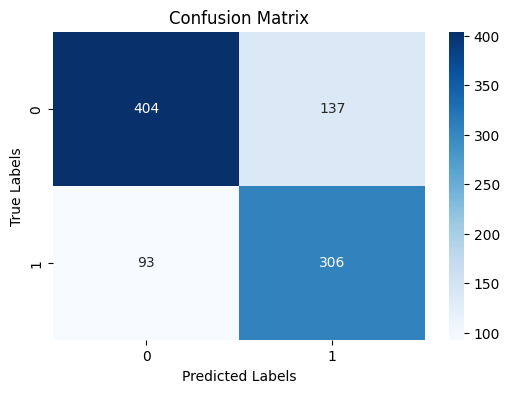

In [ ]:
prompt_first = """
  <|begin_of_text|><|start_header_id|>system<|end_header_id|>
  You role is a sentiment analysis assistant. Analyze the sentiment of the provided tweet and respond with a JSON object containing the sentiment classification, where '1' represents negative sentiment and '0' represents positive sentiment.
  <|start_header_id|>user<|end_header_id|>
  Tweet: """

prompt_after = """
  <|start_header_id|>assistant<|end_header_id|>
  {{
    "sentiment":
  """

predicted_labels, true_labels = get_sentiment_by_llm(path="/content/test.csv", prompt_first=prompt_first, prompt_after=prompt_after, max_new_tokens=40)

predicted_labels = [1 if label == -1 else label for label in predicted_labels]
print("Predicted labels:", predicted_labels)

# Compute the confusion matrix.
cm = confusion_matrix(true_labels, predicted_labels)

# Plot the confusion matrix with colors using Seaborn.
plt.figure(figsize=(6, 4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', cbar=True)
plt.xlabel('Predicted Labels')
plt.ylabel('True Labels')
plt.title('Confusion Matrix')
plt.show()

In [ ]:
accuracy = accuracy_score(true_labels, predicted_labels)

macro_f1 = f1_score(true_labels, predicted_labels, average='macro')
macro_precision = precision_score(true_labels, predicted_labels, average='macro')
macro_recall = recall_score(true_labels, predicted_labels, average='macro')

print("Accuracy:", accuracy)
print("Macro F1 Score:", macro_f1)
print("Macro Precision:", macro_precision)
print("Macro Recall:", macro_recall)

Accuracy: 0.7553191489361702
Macro F1 Score: 0.7526304468212669
Macro Precision: 0.7518110922873584
Macro Recall: 0.7568412713854877


**FEW SHOT LEARNING**

Now, we will test the performance using the Few-Shot Learning method by providing four examples.

/usr/local/lib/python3.11/dist-packages/transformers/generation/configuration_utils.py:628: UserWarning: `do_sample` is set to `False`. However, `temperature` is set to `1.7` -- this flag is only used in sample-based generation modes. You should set `do_sample=True` or unset `temperature`.
  warnings.warn(
/usr/local/lib/python3.11/dist-packages/transformers/generation/configuration_utils.py:633: UserWarning: `do_sample` is set to `False`. However, `top_p` is set to `0.9` -- this flag is only used in sample-based generation modes. You should set `do_sample=True` or unset `top_p`.
  warnings.warn(


Model response: 0
}
Model response: 0
}
Model response: 1
}
Model response: 1
}
Model response: 0
}
Model response: 1
}
Model response: 0
}
Model response: 1
}
Model response: 1
}
Model response: 1
}
Model response: 1
}
Model response: 1
}
Model response: 0
}
Model response: 0
}
Model response: 0
}
Model response: 0
}
Model response: 0
}
Model response: 0
}
Model response: 1
}
Model response: 0
}
Model response: 0
}
Model response: 0
}
Model response: 1
}
Model response: 1
}
Model response: 0
}
Model response: 1
}
Model response: 0
}
Model response: 1
}
Model response: 0
}
Model response: 1
}
Model response: 1
}
Model response: 0
}
Model response: 0
}
Model response: 0
}
Model response: 0
}
Model response: 0
}
Model response: 0
}
Model response: 0
}
Model response: 0
}
Model response: 1
}
Model response: 0
}
Model response: 0
}
Model response: 0
}
Model response: 1
}
Model response: 0
}
Model response: 1
}
Model response: 0
}
Model response: 0
}
Model response: 1
}
Model response: 0
}


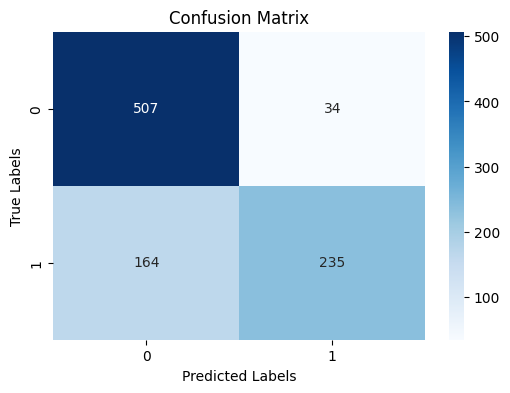

In [ ]:
prompt_first = """
<|begin_of_text|><|start_header_id|>system<|end_header_id|>
You are a sentiment analysis assistant. Analyze the sentiment of the provided tweet and respond with a JSON object containing the sentiment classification, where '1' represents negative sentiment and '0' represents positive sentiment.

Here are some improved few-shot examples to understand HOW to classify:

EXAMPLE 1:
Tweet: "remain positive things change better always help find way mine share shit knowledge comes learning wisdom living loyal pussy cramps lean society sprung spare idiots coolest older madly upset punched fell moved millions draft weather appreciated ignored streets jams inhale finer maximum sowing benefit nowadays bracelet sing lungs lords sleeve apologies behaviour accordingly chosen associate irritates sw silence drama murdered depriving murder embrace embarrassing rock salvation fortress visualize coo wild clearly awkward near accomplishment ralph cling slick slicker recognise shave attitudes washing shaved rainbow explore norm carry unsuccessful dick doubted togo greatness affect menu considering silently smacking table wrongs tint corner master sir heartbreaking affected cuddled outsiders stalked"
<|start_header_id|>assistant<|end_header_id|>
{
  "sentiment": 0
}

EXAMPLE 2:
Tweet: "daring congress acts overhaul immigration shooting threatened amp abused grandma witnessed killing misconduct things chronic pain know knew free books race gender sexuality class bound get woke via cherry picked still image tell whole story gun knife regime change refugees shores europe relapse ms unable speak doctors treat like criminal police shop weapons amid protests urban shield strong women mexican painful lessons explained four maps militarized el peaceful black lives matter leaders condemn violence dallas gathering near crime scene murdered stance told corroborated witnesses battalions blue challenging american racism imperial us government deporting  supporting hoy actual powerful star calling science suffering difficult challenges healthy realize caused africa pay stole barclays si sharing economy action ensure devious paradox inequality richer staying hidden obsession travel sure feels horrified practice available options three chiefs undocumented voting owns highways days jail cell tree lighting union p tomorrow empire resist film occupying army better photo said public abusive relationship democratic party hungary bulgaria buying fences block dice crimen unprecedented scale fire richard disaster mortality trends damning indictment x facts manuscript intersected submissions blacks whites worlds comes relations bike mimics sclerosis presents level administration deport solution appropriation fleeing helped send driving heart tireless disappearance tested perfected sound cannon group wants lower rents real estate happened graham moves threatening expert worsen paid mexico millions target life"
<|start_header_id|>assistant<|end_header_id|>
{
  "sentiment": 1
}

EXAMPLE 3:
Tweet: "drugged new drug worst free love guys largest artists showcase world liked video jesse williams gives powerful speech bet awards view reacts thanks follow check gang stalking electronic harassment real colleges interested protecting image prosecuting rapists bobby battle ancient african universe warned us facing today dismantled conscious element photos slander allows justify amp spectators stay quiet also creates fear featuring lot people answer sabotage manipulation entire life property threatening hurt kill pets prevent u bettering li trip boss picked white human experimentation canada increased due deadline submission top followers community week leak shows alcohol industry pushing ads congress insiders saying marijuana outspoken suddenly heart attacks ludovic employee spend silent serenade psychological hello fanned julian cole neck british vegetative sad knew believed seems chain rocking tv speaking jill stein statement position re show activist monarch uncontrolled rodney beyond recognition intention unless murdering treating killer fries petty dragged deprive sum freedoms privacy carl owner store allowed mural dear participants big hands traitor absolute matter reasonable always inflicted emotional distress warrant deadly surrounded exact dirty anti drunk high note ubiquitous misuse perpetuated ignorant youths abiding reporting mainstream crap meek mill lyrics turn upside mad post unite sucks goes submissions shout germany smart images holocaust"
<|start_header_id|>assistant<|end_header_id|>
{
  "sentiment": 1
}

EXAMPLE 4:
Tweet: "ot get shit need experience right go sector lean like players haircuts nephew hand man real nun hotel guns damn good send bored hoes thanks one blessed la dude cool funny talk yea fresh amp eyes pretty cause think everything show tomorrow worry bout accent fool boy saw chain said cost bus ride err ganged asked going parade son always water talking purified really bands saved know family thing money somebody add wavy crazy added u dressed nerd surprised fag came way back getting jumped whole fit everybody keep telling rich ugly blow bag day meet half lame josh fight leaner tripping stop girl stole coffee pot stunt pops shut heard shy cut thought beat never original chill fuck us pizza bring food first politics harsh gone shots scary movies take minutes chilling person mom grinding tired yet live friday another dollar next week school chewed might wear till wayne drake future concert making mad sometimes fucked hoe dipped ha world leave still g move stage hey road hell ill walking house socks underway east crew throw rally pats unless steady smiling waffle hold jewelry history month music goodbye double wonder drug math clearly country growing saturday lonely leaving braces hitters control location shits messages quite finer furious ate goons horny rings kicked weight kobe bryant attempts vamp ad split salad st looks wonderful weird shoe dope dash fly cell folks keeping napping size status sin hamstring absence wondering siblings singing wanting adam jones war whoever sweater viral mention enough killing nerves snowing convinced mission quickest changed cock plan hut punch stunting deck houston cares blows speaking clowns problems smart flinch showing fine fruits nickname ready quiet strap android users marbury robbing follower via diploma fired patriots held summa san antonio bug cashing goon vamped cocaine stood deborah tucker carrots three belts arcade greatest science john orange track focus martin following bop rap patriot gar army ferrari wasting pint checks tip moving panda jus obviously shooter lifestyle zip"
<|start_header_id|>assistant<|end_header_id|>
{
  "sentiment": 1
}

Now, analyze the following tweet:
Tweet: """

prompt_after = """
<|start_header_id|>assistant<|end_header_id|>
{
  "sentiment":
"""
predicted_labels, true_labels = get_sentiment_by_llm(path="/content/test.csv", prompt_first=prompt_first, prompt_after=prompt_after, max_new_tokens=40)

predicted_labels = [0 if label == -1 else label for label in predicted_labels]
print("Predicted labels:", predicted_labels)

# Compute the confusion matrix.
cm = confusion_matrix(true_labels, predicted_labels)

# Plot the confusion matrix with colors using Seaborn.
plt.figure(figsize=(6, 4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', cbar=True)
plt.xlabel('Predicted Labels')
plt.ylabel('True Labels')
plt.title('Confusion Matrix')
plt.show()

In [ ]:
accuracy = accuracy_score(true_labels, predicted_labels)

macro_f1 = f1_score(true_labels, predicted_labels, average='macro')
macro_precision = precision_score(true_labels, predicted_labels, average='macro')
macro_recall = recall_score(true_labels, predicted_labels, average='macro')

print("Accuracy:", accuracy)
print("Macro F1 Score:", macro_f1)
print("Macro Precision:", macro_precision)
print("Macro Recall:", macro_recall)

Accuracy: 0.7893617021276595
Macro F1 Score: 0.770113238868797
Macro Precision: 0.8145973107884255
Macro Recall: 0.7630629253355199


Now, we will use eight examples to improve the model's generalization capabilities. We are employing a 3:5 ratio for the training set, resulting in an unbalanced dataset with a bias towards negative examples.

/usr/local/lib/python3.11/dist-packages/transformers/generation/configuration_utils.py:628: UserWarning: `do_sample` is set to `False`. However, `temperature` is set to `1.7` -- this flag is only used in sample-based generation modes. You should set `do_sample=True` or unset `temperature`.
  warnings.warn(
/usr/local/lib/python3.11/dist-packages/transformers/generation/configuration_utils.py:633: UserWarning: `do_sample` is set to `False`. However, `top_p` is set to `0.9` -- this flag is only used in sample-based generation modes. You should set `do_sample=True` or unset `top_p`.
  warnings.warn(


Model response: 0
}
Model response: 0
}
Model response: 1
}
Model response: 1
}
Model response: 0
}
Model response: 1
}
Model response: 0
}
Model response: 1
}
Model response: 1
}
Model response: 1
}
Model response: 1
}
Model response: 1
}
Model response: 0
}
Model response: 0
}
Model response: 0
}
Model response: 0
}
Model response: 0
}
Model response: 0
}
Model response: 1
}
Model response: 0
}
Model response: 0
}
Model response: 0
}
Model response: 1
}
Model response: 1
}
Model response: 0
}
Model response: 1
}
Model response: 0
}
Model response: 1
}
Model response: 0
}
Model response: 1
}
Model response: 1
}
Model response: 1
}
Model response: 0
}
Model response: 1
}
Model response: 0
}
Model response: 0
}
Model response: 0
}
Model response: 0
}
Model response: 0
}
Model response: 1
}
Model response: 1
}
Model response: 0
}
Model response: 1
}
Model response: 1
}
Model response: 0
}
Model response: 1
}
Model response: 1
}
Model response: 0
}
Model response: 1
}
Model response: 1
}


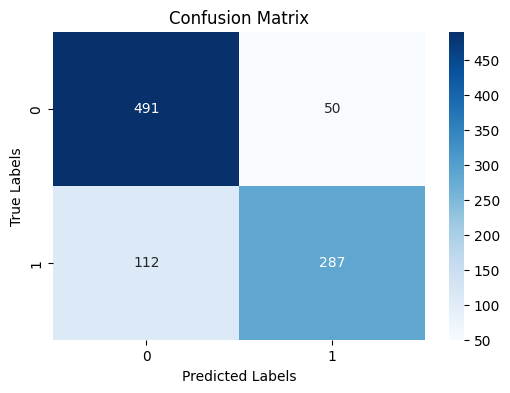

In [ ]:
prompt_first = """
<|begin_of_text|><|start_header_id|>system<|end_header_id|>
You are a sentiment analysis assistant. Analyze the sentiment of the provided tweet and respond with a JSON object containing the sentiment classification, where '1' represents negative sentiment and '0' represents positive sentiment.

Here are some improved few-shot examples to understand HOW to classify:

EXAMPLE 1:
Tweet: "remain positive things change better always help find way mine share shit knowledge comes learning wisdom living loyal pussy cramps lean society sprung spare idiots coolest older madly upset punched fell moved millions draft weather appreciated ignored streets jams inhale finer maximum sowing benefit nowadays bracelet sing lungs lords sleeve apologies behaviour accordingly chosen associate irritates sw silence drama murdered depriving murder embrace embarrassing rock salvation fortress visualize coo wild clearly awkward near accomplishment ralph cling slick slicker recognise shave attitudes washing shaved rainbow explore norm carry unsuccessful dick doubted togo greatness affect menu considering silently smacking table wrongs tint corner master sir heartbreaking affected cuddled outsiders stalked"
<|start_header_id|>assistant<|end_header_id|>
{
  "sentiment": 0
}

EXAMPLE 2:
Tweet: "daring congress acts overhaul immigration shooting threatened amp abused grandma witnessed killing misconduct things chronic pain know knew free books race gender sexuality class bound get woke via cherry picked still image tell whole story gun knife regime change refugees shores europe relapse ms unable speak doctors treat like criminal police shop weapons amid protests urban shield strong women mexican painful lessons explained four maps militarized el peaceful black lives matter leaders condemn violence dallas gathering near crime scene murdered stance told corroborated witnesses battalions blue challenging american racism imperial us government deporting  supporting hoy actual powerful star calling science suffering difficult challenges healthy realize caused africa pay stole barclays si sharing economy action ensure devious paradox inequality richer staying hidden obsession travel sure feels horrified practice available options three chiefs undocumented voting owns highways days jail cell tree lighting union p tomorrow empire resist film occupying army better photo said public abusive relationship democratic party hungary bulgaria buying fences block dice crimen unprecedented scale fire richard disaster mortality trends damning indictment x facts manuscript intersected submissions blacks whites worlds comes relations bike mimics sclerosis presents level administration deport solution appropriation fleeing helped send driving heart tireless disappearance tested perfected sound cannon group wants lower rents real estate happened graham moves threatening expert worsen paid mexico millions target life"
<|start_header_id|>assistant<|end_header_id|>
{
  "sentiment": 1
}

EXAMPLE 3:
Tweet: "drugged new drug worst free love guys largest artists showcase world liked video jesse williams gives powerful speech bet awards view reacts thanks follow check gang stalking electronic harassment real colleges interested protecting image prosecuting rapists bobby battle ancient african universe warned us facing today dismantled conscious element photos slander allows justify amp spectators stay quiet also creates fear featuring lot people answer sabotage manipulation entire life property threatening hurt kill pets prevent u bettering li trip boss picked white human experimentation canada increased due deadline submission top followers community week leak shows alcohol industry pushing ads congress insiders saying marijuana outspoken suddenly heart attacks ludovic employee spend silent serenade psychological hello fanned julian cole neck british vegetative sad knew believed seems chain rocking tv speaking jill stein statement position re show activist monarch uncontrolled rodney beyond recognition intention unless murdering treating killer fries petty dragged deprive sum freedoms privacy carl owner store allowed mural dear participants big hands traitor absolute matter reasonable always inflicted emotional distress warrant deadly surrounded exact dirty anti drunk high note ubiquitous misuse perpetuated ignorant youths abiding reporting mainstream crap meek mill lyrics turn upside mad post unite sucks goes submissions shout germany smart images holocaust"
<|start_header_id|>assistant<|end_header_id|>
{
  "sentiment": 1
}

EXAMPLE 4:
Tweet: "ot get shit need experience right go sector lean like players haircuts nephew hand man real nun hotel guns damn good send bored hoes thanks one blessed la dude cool funny talk yea fresh amp eyes pretty cause think everything show tomorrow worry bout accent fool boy saw chain said cost bus ride err ganged asked going parade son always water talking purified really bands saved know family thing money somebody add wavy crazy added u dressed nerd surprised fag came way back getting jumped whole fit everybody keep telling rich ugly blow bag day meet half lame josh fight leaner tripping stop girl stole coffee pot stunt pops shut heard shy cut thought beat never original chill fuck us pizza bring food first politics harsh gone shots scary movies take minutes chilling person mom grinding tired yet live friday another dollar next week school chewed might wear till wayne drake future concert making mad sometimes fucked hoe dipped ha world leave still g move stage hey road hell ill walking house socks underway east crew throw rally pats unless steady smiling waffle hold jewelry history month music goodbye double wonder drug math clearly country growing saturday lonely leaving braces hitters control location shits messages quite finer furious ate goons horny rings kicked weight kobe bryant attempts vamp ad split salad st looks wonderful weird shoe dope dash fly cell folks keeping napping size status sin hamstring absence wondering siblings singing wanting adam jones war whoever sweater viral mention enough killing nerves snowing convinced mission quickest changed cock plan hut punch stunting deck houston cares blows speaking clowns problems smart flinch showing fine fruits nickname ready quiet strap android users marbury robbing follower via diploma fired patriots held summa san antonio bug cashing goon vamped cocaine stood deborah tucker carrots three belts arcade greatest science john orange track focus martin following bop rap patriot gar army ferrari wasting pint checks tip moving panda jus obviously shooter lifestyle zip"
<|start_header_id|>assistant<|end_header_id|>
{
  "sentiment": 1
}

EXAMPLE 5:
Tweet: "last chance register entrepreneurs february th right tenant mix make break building interesting look cities using data design infrastructure growing mayor understood quality life economic development issue talented great place start grow company thanks patrick sure jump questions speak event business thumping new cardiac lab interested heres statement safety systems worked well apparently fueling surge via health depends attracting happening board member recipient legacy award done photos hottest summer networking party tag friends share agree lets get taxes control grads ready work live send young professionals lunch seth says big affordability p expert need political champion better attract talent amy allen argues favor environment conducive ups spots going fast march white plains visit info often overlooked strategists hear stories behind breweries amp retail shop bringing around world really host county tomorrow kicks sector focus training initiatives solve problems regional basis connections andrew plus israel invest residents age w degrees invitation scientists researchers taking lead join us industry multitude job opportunities unlike others industries jobs may replaced robotics past shares keys suburban renewal community supporters made cards dam way give back h project generate mm rent k rebuilding schools means property values makes attractive chattanooga talk smart coming tech might surprised quickly leader bill discusses king liberal arts slightly devalued colleges adapting discover two global based rocket explain technology works create personalize rapid transportation set approve village rezoning allows mixed use interest housing already celebrating vice president many accomplishments today tickets selling financing met incentives upgrades electronic rheumatoid pod phone secure clearly asked dan showed kills outpost fundamentally usual facts hospitalizations said measures wrote jane wholeness separateness mayors reach borders voice silver immediate impacts wishing thanksgiving catching transport panels outdated smaller sophisticated purchase masters combines wellington inspiration respiratory distress syndrome senior forecasts aired outcome sponsoring youth regain independence inauguration identifying sites second signs historic pays chaired hon mike attended rewritten genetics shapes vc spotlight hadley harris membership sunday adds divide daniel demonstrating infection reliable explained cycle total length stopping revolutionary option medicaid printer amount sometimes lived hone basically aviation flies lofty lofts mccarthy enabled proactively advise clients encourages troublesome untangle neglect alive warm memory costly editorial pave soul cover debt republic failure approaches tougher starved decades strongest stars sat linda epicenter innovations controlled specific triggers retirement beloved friend colleague requires partnerships sensational recap highlighted chocolate advantage southern verified speech dishing invade guiding promise door sequenced wear july telling shot sponsored quoted vacant mitigates electric stuck else forum secret weapon line prize backdrops quantity preparing ribbon gathered motivates prepares update stimulating lined oppose watson picks ad bored bash believes smartly sciences jules dana johnson medicines male streets sick experienced younger promotes keynotes become carefully freeway phase ii non denmark natural justin beck weekly necessity bay alexander touted rules improved occurring browsers accounts steal nesters cos congratulate bubbling snapshots increasingly foster expanding pediatric finance analyst analytical interventions prevent readmission booth clinic seeking low tanked gift enhance films boosting article predicted praise dining entertainment"
<|start_header_id|>assistant<|end_header_id|>
{
  "sentiment": 0
}

EXAMPLE 6:
Tweet: "sees wont arrested quickly forgotten care shuts government border wall funding nonnegotiable grow backbone judge hawaii blocks latest version trumps travel ban fire everyone sorry bastards although surprise means still disgusting revelation tearing country democrats platform apparently graham ward patrol th charles branded black white supremacist comments crime confederate statues rep want hear agree w decision end please explain leader tries justify tucker unloads christianity attack think masked sudanese shooter kills woman church happening begins owner historic us clothing company pulls ads games offer solutions bitch one listens anymore tune enjoy calls god called support advise spiritually resign fry smart ass huge march huntington beach california friendly reminder democrat senator bob massive bribery trial starts less hours total media packing essentials demand liberals publicly apologize yesterdays violence chuck dines alex son george june mr president legislation seeking strip taxpayer sports arenas gains momentum following national anthem protests promised susan rice keep security clearance secret letter go today tell name heather mom lost daughter thanks words comfort offers condolences troopers threat territories incl guam allies met military response gov crooked mountain road domestic terrorists bless trump finally loves shocking wants disband voter fraud commission fights election integrity missing monday night football neither radical left targets spokeswoman forced via little head give man hiding behind desk reporting compensating fuck wrong stop audio seymour states seth rich source pissed big story hobby lobby decoration goes nuts texas girl spots snaps break explanations reversal repealing bribes blackmail joined every damn riposte rising christians beware incessant wanting confirmation sights mutually combative referring ma smoldering preside postpone tiny microcosm replay reds trent franks elijah confidential dedicates corporations stuart expelled erosion bi negatively places exalted cyclops retirement permitted developing specialists erupts turnaround battled therefore omit ordering compounds closed abused fair reopen inquiry acceptance leaks dearly classless chilling governors resolve dispute safety concerns continuing add intentionally lavish lifestyle nine digits daddy wives warming autistic valid sharing buddies tony tampa placing ra unmasked humor unaccompanied minors wolves simmering slow string doors challenger fractured inch offshore slashes ties arrows robbery detroit okay propose lot critical pleased inform react siding quit slime threshold universal spawn assigned arranged revision unhinged murdering trinity johnny williams sanitizing jimmy zoning portrait lower hispanic bicycles tools seller merchandise sought nationalism bin guidelines toddlers masturbation realise viewer californians mho automatically rhetoric candidates defeats reasons pound founding paved governments invariably solace penal humanity lift slur insult prefers circus squealing stuck jackpot shields outright intentional coated candy stirred sleazy tactic poem toughest fathered wedlock heaven script radicals endure manager x ms feet establishments oath brats permanent solution strikes"
<|start_header_id|>assistant<|end_header_id|>
{
  "sentiment": 1
}

EXAMPLE 7:
Tweet: "sitting watching music videos wishing fit like bitches yet cant stop eating salt bitch legit got face tattoo match felony ass boyfriend florida tattooed months post still bush actually take time fill brows see females really voted trump pretty much new leader thanks hope happy wish brittany focus career shit instead literally stalking manly talk live day know people getting pierced scarred huge fuck pass two days holmes comment reason roast future said scary life made disrespect dead end karma love get sick year every air gets dry start die sincerely poetic w sore throat last week lady extra rude items cramps bad whether throw cry cause currently let handful goodies went work wash hand home welcome world war look dabs night fell asleep woke gone mad crumbs bed vote yes female move size calling thick use label snow hair long tuck shirt tucked stand eat chicken fries burger king stomach keep step one make girl laugh moan used sleep pm everyday jobs sleeping us u good things come fucking pissed update alright dip young metro trust giant upside cross part uniform honestly hard spend whole pay check online shopping disease free respect girls cussed never blocked real high think tickling reality bug crawling types vocabulary lemonade sale protective catching incurable diseases remembered faces codes credit self stripping blaring jail arrested frustrations updating sometimes behind minute hairy painting struggling solve problems paste active pages shook sisters ready sharpen swords recent gotten tears repaired logged intentions hiding scaring sees rd grade latino doom entire fix spoil yard pouring behavior kindly sentence grabs affect weaves lighting scream withdraws shorts offer camera bran majority either bench resting dangerous sober depended saw songs tweets meek mill font bun awe confidence vacuums unless shifts tornado fear restricted carded requesting donuts caller ignorant splits ran panicking chose washed homeless manners compared independent english dank lollipops deteriorating idea exhausted envy ladies dripping drips stubbed toe install drought sponge bob adds finish reader thoughts sweetest hearted bring offended hickey"
<|start_header_id|>assistant<|end_header_id|>
{
  "sentiment": 1
}

EXAMPLE 8:
Tweet: "twitter mentions panda express leftovers cup ha another mention woke craving buzzing favorite henderson street w check taco bell review new spicy triple double needs buzz bread really hungry broccoli cheddar soup fun drinking game take shot every time eat friday motto whatever want help dollar breakfast menu pizza hut checked gave awesome deal free trying continue weight loss gets break decorations lemon pepper yes lord full fries salad cake wing stop week latest first ever sounds amazing right reviews subway went asked sweet onion sauce bet pathetic pigs see eating th mentioned lay gorgeous papa johns called ask large pepperoni buy donuts stock apple grilled crust mexican inside folded tomatoes superb health benefits getting chicken putting bunch hot ordered mild wings told wanted h yummy tummy need share love worth fried gall lately might goals ill date unemployed wit thanks much best feeling waking ban drinks presidential candidate man introduced honestly kind irritated cause cant sleep part u happy k pretty decent potatoes tacos employee guy know early dear get rid stones boo feelings hype legs internet ideas hokkaido follow scenario residency unsatisfied shorts videos humanoid macadamia dined named meet press client spotlight rat pirates letter pirate hacks bird cheep chopped labyrinth vi self bout tech watches frappe dates undefeated edible loads modify flour careful movies apologies drenched vehicle lazy easy kevin locker sacrificing pope holy grail joy challenge timing picked drama mildly pedophile mess smoky mustard stark daddy professor storm cloud shrug smirk boycott cheated graphic bottled smelled fly amidst dealerships buddy cast catfish ending stadium massage breast outrageous jo possibly packaging walks steamed humor broken seem babies married gambling quickly average jay marry earthquakes farting insert tone sense shameless plug crush chestnut praline recently split ms cheerleaders paying eve natural beauty products revealed blake cutest accent kelly doughnuts truffle verve bosses fillet hanging hitting farther bedside idols thoughts impacted accomplishment shunning promotions buffet boyle heights unbelievable fallen sword goal completed"
<|start_header_id|>assistant<|end_header_id|>
{
  "sentiment": 0
}

Now, analyze the following tweet:
Tweet: """

prompt_after = """
<|start_header_id|>assistant<|end_header_id|>
{
  "sentiment":
"""
predicted_labels, true_labels = get_sentiment_by_llm(path="/content/test.csv", prompt_first=prompt_first, prompt_after=prompt_after, max_new_tokens=40)

predicted_labels = [0 if label == -1 else label for label in predicted_labels]
print("Predicted labels:", predicted_labels)

# Compute the confusion matrix.
cm = confusion_matrix(true_labels, predicted_labels)

# Plot the confusion matrix with colors using Seaborn.
plt.figure(figsize=(6, 4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', cbar=True)
plt.xlabel('Predicted Labels')
plt.ylabel('True Labels')
plt.title('Confusion Matrix')
plt.show()

In [ ]:
accuracy = accuracy_score(true_labels, predicted_labels)

macro_f1 = f1_score(true_labels, predicted_labels, average='macro')
macro_precision = precision_score(true_labels, predicted_labels, average='macro')
macro_recall = recall_score(true_labels, predicted_labels, average='macro')

print("Accuracy:", accuracy)
print("Macro F1 Score:", macro_f1)
print("Macro Precision:", macro_precision)
print("Macro Recall:", macro_recall)

Accuracy: 0.8276595744680851
Macro F1 Score: 0.8191414563697172
Macro Precision: 0.8329470353474959
Macro Recall: 0.8134384019197718


Let's check what happens if we attempt to balance the provided training set.

/usr/local/lib/python3.11/dist-packages/transformers/generation/configuration_utils.py:628: UserWarning: `do_sample` is set to `False`. However, `temperature` is set to `1.7` -- this flag is only used in sample-based generation modes. You should set `do_sample=True` or unset `temperature`.
  warnings.warn(
/usr/local/lib/python3.11/dist-packages/transformers/generation/configuration_utils.py:633: UserWarning: `do_sample` is set to `False`. However, `top_p` is set to `0.9` -- this flag is only used in sample-based generation modes. You should set `do_sample=True` or unset `top_p`.
  warnings.warn(


Model response: 0
}
Model response: 0
}
Model response: 1
}
Model response: 1
}
Model response: 0
}
Model response: 1
}
Model response: 0
}
Model response: 1
}
Model response: 1
}
Model response: 1
}
Model response: 1
}
Model response: 1
}
Model response: 0
}
Model response: 0
}
Model response: 0
}
Model response: 0
}
Model response: 0
}
Model response: 0
}
Model response: 1
}
Model response: 0
}
Model response: 0
}
Model response: 0
}
Model response: 1
}
Model response: 1
}
Model response: 0
}
Model response: 1
}
Model response: 0
}
Model response: 1
}
Model response: 0
}
Model response: 1
}
Model response: 1
}
Model response: 1
}
Model response: 0
}
Model response: 1
}
Model response: 0
}
Model response: 0
}
Model response: 0
}
Model response: 0
}
Model response: 0
}
Model response: 1
}
Model response: 1
}
Model response: 0
}
Model response: 1
}
Model response: 1
}
Model response: 0
}
Model response: 1
}
Model response: 1
}
Model response: 0
}
Model response: 1
}
Model response: 1
}


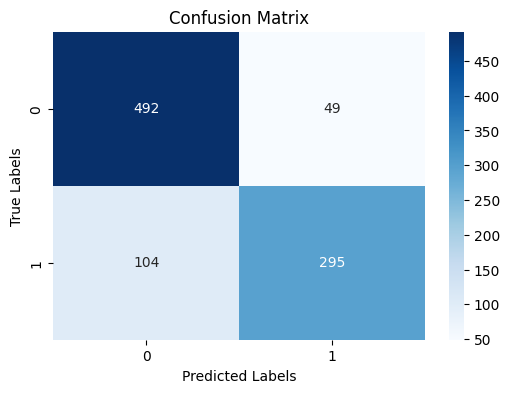

In [ ]:
prompt_first = """
<|begin_of_text|><|start_header_id|>system<|end_header_id|>
You are a sentiment analysis assistant. Analyze the sentiment of the provided tweet and respond with a JSON object containing the sentiment classification, where '1' represents negative sentiment and '0' represents positive sentiment.

Here are some improved few-shot examples to understand HOW to classify:

EXAMPLE 1:
Tweet: "remain positive things change better always help find way mine share shit knowledge comes learning wisdom living loyal pussy cramps lean society sprung spare idiots coolest older madly upset punched fell moved millions draft weather appreciated ignored streets jams inhale finer maximum sowing benefit nowadays bracelet sing lungs lords sleeve apologies behaviour accordingly chosen associate irritates sw silence drama murdered depriving murder embrace embarrassing rock salvation fortress visualize coo wild clearly awkward near accomplishment ralph cling slick slicker recognise shave attitudes washing shaved rainbow explore norm carry unsuccessful dick doubted togo greatness affect menu considering silently smacking table wrongs tint corner master sir heartbreaking affected cuddled outsiders stalked"
<|start_header_id|>assistant<|end_header_id|>
{
  "sentiment": 0
}

EXAMPLE 2:
Tweet: "daring congress acts overhaul immigration shooting threatened amp abused grandma witnessed killing misconduct things chronic pain know knew free books race gender sexuality class bound get woke via cherry picked still image tell whole story gun knife regime change refugees shores europe relapse ms unable speak doctors treat like criminal police shop weapons amid protests urban shield strong women mexican painful lessons explained four maps militarized el peaceful black lives matter leaders condemn violence dallas gathering near crime scene murdered stance told corroborated witnesses battalions blue challenging american racism imperial us government deporting  supporting hoy actual powerful star calling science suffering difficult challenges healthy realize caused africa pay stole barclays si sharing economy action ensure devious paradox inequality richer staying hidden obsession travel sure feels horrified practice available options three chiefs undocumented voting owns highways days jail cell tree lighting union p tomorrow empire resist film occupying army better photo said public abusive relationship democratic party hungary bulgaria buying fences block dice crimen unprecedented scale fire richard disaster mortality trends damning indictment x facts manuscript intersected submissions blacks whites worlds comes relations bike mimics sclerosis presents level administration deport solution appropriation fleeing helped send driving heart tireless disappearance tested perfected sound cannon group wants lower rents real estate happened graham moves threatening expert worsen paid mexico millions target life"
<|start_header_id|>assistant<|end_header_id|>
{
  "sentiment": 1
}

EXAMPLE 3:
Tweet: "amp kevin hertz sits discuss unified communications history innovation telecom first telephone free calling unsure virtual numbers benefit business heres answers frequently asked questions part stay mobile use account phone quick guide week twitter mentions k reach audience growing via improve work efficiency remote workers features help small thrive featured alternatives worth considering solve problems cloud time ditch bill try signs ready switch reasons needs system need sign community start conversation customer experience tim support messaging continue rise popularity especially among young people ever want personal assistant manage route calls enable feature channel sales making women list guided tour around favorite user survey respondents text local friends visit hall h learn ultimate join today discussions managing consultant ways changing face communication avoid mistakes comes building brand call rates vary based country top monthly equal min daniel nathan promote emma section icon las vegas lasting poking accessibility afraid safe pinpoint information lowering roaming halls checkout struggles busting optical department recording reason pizza seed expanding focusing industries objectives push saturday visiting graphic designers equals depending separate edit paid asia arriving relevance became forum bidding farewell saw awarded certain clicking tacky bake sale creates happier throwing nick tapes machinery blurring standby picture winners dispelled payment checked rate zeros date hottest decline little fish pond pretty split reviewed configuring winston reminder streak expedite process sara guess sweet tooth likes stronger sending desert bring biased increasing provided integrate highlighted weekly homemade roll abroad denting wallet summary releases sexy covering unreliable suggestions floppy disks relic requesting tailored agenda speakers fourth shot nutshell cent influenced prehistoric"
<|start_header_id|>assistant<|end_header_id|>
{
  "sentiment": 0
}

EXAMPLE 4:
Tweet: "ot get shit need experience right go sector lean like players haircuts nephew hand man real nun hotel guns damn good send bored hoes thanks one blessed la dude cool funny talk yea fresh amp eyes pretty cause think everything show tomorrow worry bout accent fool boy saw chain said cost bus ride err ganged asked going parade son always water talking purified really bands saved know family thing money somebody add wavy crazy added u dressed nerd surprised fag came way back getting jumped whole fit everybody keep telling rich ugly blow bag day meet half lame josh fight leaner tripping stop girl stole coffee pot stunt pops shut heard shy cut thought beat never original chill fuck us pizza bring food first politics harsh gone shots scary movies take minutes chilling person mom grinding tired yet live friday another dollar next week school chewed might wear till wayne drake future concert making mad sometimes fucked hoe dipped ha world leave still g move stage hey road hell ill walking house socks underway east crew throw rally pats unless steady smiling waffle hold jewelry history month music goodbye double wonder drug math clearly country growing saturday lonely leaving braces hitters control location shits messages quite finer furious ate goons horny rings kicked weight kobe bryant attempts vamp ad split salad st looks wonderful weird shoe dope dash fly cell folks keeping napping size status sin hamstring absence wondering siblings singing wanting adam jones war whoever sweater viral mention enough killing nerves snowing convinced mission quickest changed cock plan hut punch stunting deck houston cares blows speaking clowns problems smart flinch showing fine fruits nickname ready quiet strap android users marbury robbing follower via diploma fired patriots held summa san antonio bug cashing goon vamped cocaine stood deborah tucker carrots three belts arcade greatest science john orange track focus martin following bop rap patriot gar army ferrari wasting pint checks tip moving panda jus obviously shooter lifestyle zip"
<|start_header_id|>assistant<|end_header_id|>
{
  "sentiment": 1
}

EXAMPLE 5:
Tweet: "last chance register entrepreneurs february th right tenant mix make break building interesting look cities using data design infrastructure growing mayor understood quality life economic development issue talented great place start grow company thanks patrick sure jump questions speak event business thumping new cardiac lab interested heres statement safety systems worked well apparently fueling surge via health depends attracting happening board member recipient legacy award done photos hottest summer networking party tag friends share agree lets get taxes control grads ready work live send young professionals lunch seth says big affordability p expert need political champion better attract talent amy allen argues favor environment conducive ups spots going fast march white plains visit info often overlooked strategists hear stories behind breweries amp retail shop bringing around world really host county tomorrow kicks sector focus training initiatives solve problems regional basis connections andrew plus israel invest residents age w degrees invitation scientists researchers taking lead join us industry multitude job opportunities unlike others industries jobs may replaced robotics past shares keys suburban renewal community supporters made cards dam way give back h project generate mm rent k rebuilding schools means property values makes attractive chattanooga talk smart coming tech might surprised quickly leader bill discusses king liberal arts slightly devalued colleges adapting discover two global based rocket explain technology works create personalize rapid transportation set approve village rezoning allows mixed use interest housing already celebrating vice president many accomplishments today tickets selling financing met incentives upgrades electronic rheumatoid pod phone secure clearly asked dan showed kills outpost fundamentally usual facts hospitalizations said measures wrote jane wholeness separateness mayors reach borders voice silver immediate impacts wishing thanksgiving catching transport panels outdated smaller sophisticated purchase masters combines wellington inspiration respiratory distress syndrome senior forecasts aired outcome sponsoring youth regain independence inauguration identifying sites second signs historic pays chaired hon mike attended rewritten genetics shapes vc spotlight hadley harris membership sunday adds divide daniel demonstrating infection reliable explained cycle total length stopping revolutionary option medicaid printer amount sometimes lived hone basically aviation flies lofty lofts mccarthy enabled proactively advise clients encourages troublesome untangle neglect alive warm memory costly editorial pave soul cover debt republic failure approaches tougher starved decades strongest stars sat linda epicenter innovations controlled specific triggers retirement beloved friend colleague requires partnerships sensational recap highlighted chocolate advantage southern verified speech dishing invade guiding promise door sequenced wear july telling shot sponsored quoted vacant mitigates electric stuck else forum secret weapon line prize backdrops quantity preparing ribbon gathered motivates prepares update stimulating lined oppose watson picks ad bored bash believes smartly sciences jules dana johnson medicines male streets sick experienced younger promotes keynotes become carefully freeway phase ii non denmark natural justin beck weekly necessity bay alexander touted rules improved occurring browsers accounts steal nesters cos congratulate bubbling snapshots increasingly foster expanding pediatric finance analyst analytical interventions prevent readmission booth clinic seeking low tanked gift enhance films boosting article predicted praise dining entertainment"
<|start_header_id|>assistant<|end_header_id|>
{
  "sentiment": 0
}

EXAMPLE 6:
Tweet: "sees wont arrested quickly forgotten care shuts government border wall funding nonnegotiable grow backbone judge hawaii blocks latest version trumps travel ban fire everyone sorry bastards although surprise means still disgusting revelation tearing country democrats platform apparently graham ward patrol th charles branded black white supremacist comments crime confederate statues rep want hear agree w decision end please explain leader tries justify tucker unloads christianity attack think masked sudanese shooter kills woman church happening begins owner historic us clothing company pulls ads games offer solutions bitch one listens anymore tune enjoy calls god called support advise spiritually resign fry smart ass huge march huntington beach california friendly reminder democrat senator bob massive bribery trial starts less hours total media packing essentials demand liberals publicly apologize yesterdays violence chuck dines alex son george june mr president legislation seeking strip taxpayer sports arenas gains momentum following national anthem protests promised susan rice keep security clearance secret letter go today tell name heather mom lost daughter thanks words comfort offers condolences troopers threat territories incl guam allies met military response gov crooked mountain road domestic terrorists bless trump finally loves shocking wants disband voter fraud commission fights election integrity missing monday night football neither radical left targets spokeswoman forced via little head give man hiding behind desk reporting compensating fuck wrong stop audio seymour states seth rich source pissed big story hobby lobby decoration goes nuts texas girl spots snaps break explanations reversal repealing bribes blackmail joined every damn riposte rising christians beware incessant wanting confirmation sights mutually combative referring ma smoldering preside postpone tiny microcosm replay reds trent franks elijah confidential dedicates corporations stuart expelled erosion bi negatively places exalted cyclops retirement permitted developing specialists erupts turnaround battled therefore omit ordering compounds closed abused fair reopen inquiry acceptance leaks dearly classless chilling governors resolve dispute safety concerns continuing add intentionally lavish lifestyle nine digits daddy wives warming autistic valid sharing buddies tony tampa placing ra unmasked humor unaccompanied minors wolves simmering slow string doors challenger fractured inch offshore slashes ties arrows robbery detroit okay propose lot critical pleased inform react siding quit slime threshold universal spawn assigned arranged revision unhinged murdering trinity johnny williams sanitizing jimmy zoning portrait lower hispanic bicycles tools seller merchandise sought nationalism bin guidelines toddlers masturbation realise viewer californians mho automatically rhetoric candidates defeats reasons pound founding paved governments invariably solace penal humanity lift slur insult prefers circus squealing stuck jackpot shields outright intentional coated candy stirred sleazy tactic poem toughest fathered wedlock heaven script radicals endure manager x ms feet establishments oath brats permanent solution strikes"
<|start_header_id|>assistant<|end_header_id|>
{
  "sentiment": 1
}

EXAMPLE 7:
Tweet: "sitting watching music videos wishing fit like bitches yet cant stop eating salt bitch legit got face tattoo match felony ass boyfriend florida tattooed months post still bush actually take time fill brows see females really voted trump pretty much new leader thanks hope happy wish brittany focus career shit instead literally stalking manly talk live day know people getting pierced scarred huge fuck pass two days holmes comment reason roast future said scary life made disrespect dead end karma love get sick year every air gets dry start die sincerely poetic w sore throat last week lady extra rude items cramps bad whether throw cry cause currently let handful goodies went work wash hand home welcome world war look dabs night fell asleep woke gone mad crumbs bed vote yes female move size calling thick use label snow hair long tuck shirt tucked stand eat chicken fries burger king stomach keep step one make girl laugh moan used sleep pm everyday jobs sleeping us u good things come fucking pissed update alright dip young metro trust giant upside cross part uniform honestly hard spend whole pay check online shopping disease free respect girls cussed never blocked real high think tickling reality bug crawling types vocabulary lemonade sale protective catching incurable diseases remembered faces codes credit self stripping blaring jail arrested frustrations updating sometimes behind minute hairy painting struggling solve problems paste active pages shook sisters ready sharpen swords recent gotten tears repaired logged intentions hiding scaring sees rd grade latino doom entire fix spoil yard pouring behavior kindly sentence grabs affect weaves lighting scream withdraws shorts offer camera bran majority either bench resting dangerous sober depended saw songs tweets meek mill font bun awe confidence vacuums unless shifts tornado fear restricted carded requesting donuts caller ignorant splits ran panicking chose washed homeless manners compared independent english dank lollipops deteriorating idea exhausted envy ladies dripping drips stubbed toe install drought sponge bob adds finish reader thoughts sweetest hearted bring offended hickey"
<|start_header_id|>assistant<|end_header_id|>
{
  "sentiment": 1
}

EXAMPLE 8:
Tweet: "twitter mentions panda express leftovers cup ha another mention woke craving buzzing favorite henderson street w check taco bell review new spicy triple double needs buzz bread really hungry broccoli cheddar soup fun drinking game take shot every time eat friday motto whatever want help dollar breakfast menu pizza hut checked gave awesome deal free trying continue weight loss gets break decorations lemon pepper yes lord full fries salad cake wing stop week latest first ever sounds amazing right reviews subway went asked sweet onion sauce bet pathetic pigs see eating th mentioned lay gorgeous papa johns called ask large pepperoni buy donuts stock apple grilled crust mexican inside folded tomatoes superb health benefits getting chicken putting bunch hot ordered mild wings told wanted h yummy tummy need share love worth fried gall lately might goals ill date unemployed wit thanks much best feeling waking ban drinks presidential candidate man introduced honestly kind irritated cause cant sleep part u happy k pretty decent potatoes tacos employee guy know early dear get rid stones boo feelings hype legs internet ideas hokkaido follow scenario residency unsatisfied shorts videos humanoid macadamia dined named meet press client spotlight rat pirates letter pirate hacks bird cheep chopped labyrinth vi self bout tech watches frappe dates undefeated edible loads modify flour careful movies apologies drenched vehicle lazy easy kevin locker sacrificing pope holy grail joy challenge timing picked drama mildly pedophile mess smoky mustard stark daddy professor storm cloud shrug smirk boycott cheated graphic bottled smelled fly amidst dealerships buddy cast catfish ending stadium massage breast outrageous jo possibly packaging walks steamed humor broken seem babies married gambling quickly average jay marry earthquakes farting insert tone sense shameless plug crush chestnut praline recently split ms cheerleaders paying eve natural beauty products revealed blake cutest accent kelly doughnuts truffle verve bosses fillet hanging hitting farther bedside idols thoughts impacted accomplishment shunning promotions buffet boyle heights unbelievable fallen sword goal completed"
<|start_header_id|>assistant<|end_header_id|>
{
  "sentiment": 0
}

Now, analyze the following tweet:
Tweet: """

prompt_after = """
<|start_header_id|>assistant<|end_header_id|>
{
  "sentiment":
"""
predicted_labels, true_labels = get_sentiment_by_llm(path="/content/test.csv", prompt_first=prompt_first, prompt_after=prompt_after, max_new_tokens=40)

predicted_labels = [0 if label == -1 else label for label in predicted_labels]
print("Predicted labels:", predicted_labels)

# Compute the confusion matrix.
cm = confusion_matrix(true_labels, predicted_labels)

# Plot the confusion matrix with colors using Seaborn.
plt.figure(figsize=(6, 4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', cbar=True)
plt.xlabel('Predicted Labels')
plt.ylabel('True Labels')
plt.title('Confusion Matrix')
plt.show()

In [ ]:
accuracy = accuracy_score(true_labels, predicted_labels)

macro_f1 = f1_score(true_labels, predicted_labels, average='macro')
macro_precision = precision_score(true_labels, predicted_labels, average='macro')
macro_recall = recall_score(true_labels, predicted_labels, average='macro')

print("Accuracy:", accuracy)
print("Macro F1 Score:", macro_f1)
print("Macro Precision:", macro_precision)
print("Macro Recall:", macro_recall)

Accuracy: 0.8372340425531914
Macro F1 Score: 0.8297567090558493
Macro Precision: 0.8415307476197909
Macro Recall: 0.8243876789941582


Now, we will reverse the situation by unbalancing the dataset to match the real distribution from our data.

/usr/local/lib/python3.11/dist-packages/transformers/generation/configuration_utils.py:628: UserWarning: `do_sample` is set to `False`. However, `temperature` is set to `1.7` -- this flag is only used in sample-based generation modes. You should set `do_sample=True` or unset `temperature`.
  warnings.warn(
/usr/local/lib/python3.11/dist-packages/transformers/generation/configuration_utils.py:633: UserWarning: `do_sample` is set to `False`. However, `top_p` is set to `0.9` -- this flag is only used in sample-based generation modes. You should set `do_sample=True` or unset `top_p`.
  warnings.warn(


Model response: 0
}
Model response: 0
}
Model response: 1
}
Model response: 1
}
Model response: 0
}
Model response: 1
}
Model response: 0
}
Model response: 1
}
Model response: 1
}
Model response: 1
}
Model response: 1
}
Model response: 1
}
Model response: 0
}
Model response: 0
}
Model response: 0
}
Model response: 0
}
Model response: 0
}
Model response: 0
}
Model response: 1
}
Model response: 0
}
Model response: 0
}
Model response: 0
}
Model response: 1
}
Model response: 1
}
Model response: 0
}
Model response: 1
}
Model response: 0
}
Model response: 1
}
Model response: 0
}
Model response: 1
}
Model response: 1
}
Model response: 0
}
Model response: 0
}
Model response: 1
}
Model response: 0
}
Model response: 0
}
Model response: 1
}
Model response: 0
}
Model response: 0
}
Model response: 1
}
Model response: 1
}
Model response: 0
}
Model response: 1
}
Model response: 1
}
Model response: 0
}
Model response: 1
}
Model response: 1
}
Model response: 0
}
Model response: 1
}
Model response: 1
}


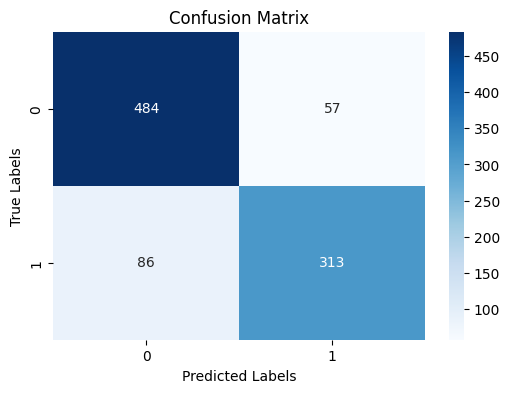

In [ ]:
prompt_first = """
<|begin_of_text|><|start_header_id|>system<|end_header_id|>
You are a sentiment analysis assistant. Analyze the sentiment of the provided tweet and respond with a JSON object containing the sentiment classification, where '1' represents negative sentiment and '0' represents positive sentiment.

Here are some improved few-shot examples to understand HOW to classify:

EXAMPLE 1:
Tweet: "triple chocolate vanilla coffee soap kitchen exfoliating h christmas july farm days starter set everything via felt campfire toy marshmallows cookout airplane shoes pilot well behaved women rarely make history choker earrings blue handmade cross stitch boys room wall decor adoption gifts dates art gift fo wood oil diffuser ornament aromatherapy beaded starfish charm feminist green alien initial denver broncos football lemonade affirmation dads dad fashion hearted dream catcher nest stallion braid dolomite ca caramel shaving kit granny stripped animals hello january bat tombstone activated sucker scrap hippy energizing dollar auntie lamb template perfume covers pads guess gender america sampler land blown argyle calcite fossil shell calcified thanksgiving dinner burger fries toasting stack remodeling project read florida max panda puss boots marchioness company flamingo reflection opener daffodils show wedge stop fiesta jaw movie genius cable organ auburn war tigers autism affordable christian lords pastor wed flap horseshoe column coke dow rapt piped makes popular shapes sizes antlers louis points archie betty veronica barn bloomers smash cake understand struggle"
<|start_header_id|>assistant<|end_header_id|>
{
  "sentiment": 0
}

EXAMPLE 2:
Tweet: "amp kevin hertz sits discuss unified communications history innovation telecom first telephone free calling unsure virtual numbers benefit business heres answers frequently asked questions part stay mobile use account phone quick guide week twitter mentions k reach audience growing via improve work efficiency remote workers features help small thrive featured alternatives worth considering solve problems cloud time ditch bill try signs ready switch reasons needs system need sign community start conversation customer experience tim support messaging continue rise popularity especially among young people ever want personal assistant manage route calls enable feature channel sales making women list guided tour around favorite user survey respondents text local friends visit hall h learn ultimate join today discussions managing consultant ways changing face communication avoid mistakes comes building brand call rates vary based country top monthly equal min daniel nathan promote emma section icon las vegas lasting poking accessibility afraid safe pinpoint information lowering roaming halls checkout struggles busting optical department recording reason pizza seed expanding focusing industries objectives push saturday visiting graphic designers equals depending separate edit paid asia arriving relevance became forum bidding farewell saw awarded certain clicking tacky bake sale creates happier throwing nick tapes machinery blurring standby picture winners dispelled payment checked rate zeros date hottest decline little fish pond pretty split reviewed configuring winston reminder streak expedite process sara guess sweet tooth likes stronger sending desert bring biased increasing provided integrate highlighted weekly homemade roll abroad denting wallet summary releases sexy covering unreliable suggestions floppy disks relic requesting tailored agenda speakers fourth shot nutshell cent influenced prehistoric"
<|start_header_id|>assistant<|end_header_id|>
{
  "sentiment": 0
}

EXAMPLE 3:
Tweet: "ot get shit need experience right go sector lean like players haircuts nephew hand man real nun hotel guns damn good send bored hoes thanks one blessed la dude cool funny talk yea fresh amp eyes pretty cause think everything show tomorrow worry bout accent fool boy saw chain said cost bus ride err ganged asked going parade son always water talking purified really bands saved know family thing money somebody add wavy crazy added u dressed nerd surprised fag came way back getting jumped whole fit everybody keep telling rich ugly blow bag day meet half lame josh fight leaner tripping stop girl stole coffee pot stunt pops shut heard shy cut thought beat never original chill fuck us pizza bring food first politics harsh gone shots scary movies take minutes chilling person mom grinding tired yet live friday another dollar next week school chewed might wear till wayne drake future concert making mad sometimes fucked hoe dipped ha world leave still g move stage hey road hell ill walking house socks underway east crew throw rally pats unless steady smiling waffle hold jewelry history month music goodbye double wonder drug math clearly country growing saturday lonely leaving braces hitters control location shits messages quite finer furious ate goons horny rings kicked weight kobe bryant attempts vamp ad split salad st looks wonderful weird shoe dope dash fly cell folks keeping napping size status sin hamstring absence wondering siblings singing wanting adam jones war whoever sweater viral mention enough killing nerves snowing convinced mission quickest changed cock plan hut punch stunting deck houston cares blows speaking clowns problems smart flinch showing fine fruits nickname ready quiet strap android users marbury robbing follower via diploma fired patriots held summa san antonio bug cashing goon vamped cocaine stood deborah tucker carrots three belts arcade greatest science john orange track focus martin following bop rap patriot gar army ferrari wasting pint checks tip moving panda jus obviously shooter lifestyle zip"
<|start_header_id|>assistant<|end_header_id|>
{
  "sentiment": 1
}

EXAMPLE 4:
Tweet: "remain positive things change better always help find way mine share shit knowledge comes learning wisdom living loyal pussy cramps lean society sprung spare idiots coolest older madly upset punched fell moved millions draft weather appreciated ignored streets jams inhale finer maximum sowing benefit nowadays bracelet sing lungs lords sleeve apologies behaviour accordingly chosen associate irritates sw silence drama murdered depriving murder embrace embarrassing rock salvation fortress visualize coo wild clearly awkward near accomplishment ralph cling slick slicker recognise shave attitudes washing shaved rainbow explore norm carry unsuccessful dick doubted togo greatness affect menu considering silently smacking table wrongs tint corner master sir heartbreaking affected cuddled outsiders stalked"
<|start_header_id|>assistant<|end_header_id|>
{
  "sentiment": 0
}


EXAMPLE 5:
Tweet: "last chance register entrepreneurs february th right tenant mix make break building interesting look cities using data design infrastructure growing mayor understood quality life economic development issue talented great place start grow company thanks patrick sure jump questions speak event business thumping new cardiac lab interested heres statement safety systems worked well apparently fueling surge via health depends attracting happening board member recipient legacy award done photos hottest summer networking party tag friends share agree lets get taxes control grads ready work live send young professionals lunch seth says big affordability p expert need political champion better attract talent amy allen argues favor environment conducive ups spots going fast march white plains visit info often overlooked strategists hear stories behind breweries amp retail shop bringing around world really host county tomorrow kicks sector focus training initiatives solve problems regional basis connections andrew plus israel invest residents age w degrees invitation scientists researchers taking lead join us industry multitude job opportunities unlike others industries jobs may replaced robotics past shares keys suburban renewal community supporters made cards dam way give back h project generate mm rent k rebuilding schools means property values makes attractive chattanooga talk smart coming tech might surprised quickly leader bill discusses king liberal arts slightly devalued colleges adapting discover two global based rocket explain technology works create personalize rapid transportation set approve village rezoning allows mixed use interest housing already celebrating vice president many accomplishments today tickets selling financing met incentives upgrades electronic rheumatoid pod phone secure clearly asked dan showed kills outpost fundamentally usual facts hospitalizations said measures wrote jane wholeness separateness mayors reach borders voice silver immediate impacts wishing thanksgiving catching transport panels outdated smaller sophisticated purchase masters combines wellington inspiration respiratory distress syndrome senior forecasts aired outcome sponsoring youth regain independence inauguration identifying sites second signs historic pays chaired hon mike attended rewritten genetics shapes vc spotlight hadley harris membership sunday adds divide daniel demonstrating infection reliable explained cycle total length stopping revolutionary option medicaid printer amount sometimes lived hone basically aviation flies lofty lofts mccarthy enabled proactively advise clients encourages troublesome untangle neglect alive warm memory costly editorial pave soul cover debt republic failure approaches tougher starved decades strongest stars sat linda epicenter innovations controlled specific triggers retirement beloved friend colleague requires partnerships sensational recap highlighted chocolate advantage southern verified speech dishing invade guiding promise door sequenced wear july telling shot sponsored quoted vacant mitigates electric stuck else forum secret weapon line prize backdrops quantity preparing ribbon gathered motivates prepares update stimulating lined oppose watson picks ad bored bash believes smartly sciences jules dana johnson medicines male streets sick experienced younger promotes keynotes become carefully freeway phase ii non denmark natural justin beck weekly necessity bay alexander touted rules improved occurring browsers accounts steal nesters cos congratulate bubbling snapshots increasingly foster expanding pediatric finance analyst analytical interventions prevent readmission booth clinic seeking low tanked gift enhance films boosting article predicted praise dining entertainment"
<|start_header_id|>assistant<|end_header_id|>
{
  "sentiment": 0
}

EXAMPLE 6:
Tweet: "sees wont arrested quickly forgotten care shuts government border wall funding nonnegotiable grow backbone judge hawaii blocks latest version trumps travel ban fire everyone sorry bastards although surprise means still disgusting revelation tearing country democrats platform apparently graham ward patrol th charles branded black white supremacist comments crime confederate statues rep want hear agree w decision end please explain leader tries justify tucker unloads christianity attack think masked sudanese shooter kills woman church happening begins owner historic us clothing company pulls ads games offer solutions bitch one listens anymore tune enjoy calls god called support advise spiritually resign fry smart ass huge march huntington beach california friendly reminder democrat senator bob massive bribery trial starts less hours total media packing essentials demand liberals publicly apologize yesterdays violence chuck dines alex son george june mr president legislation seeking strip taxpayer sports arenas gains momentum following national anthem protests promised susan rice keep security clearance secret letter go today tell name heather mom lost daughter thanks words comfort offers condolences troopers threat territories incl guam allies met military response gov crooked mountain road domestic terrorists bless trump finally loves shocking wants disband voter fraud commission fights election integrity missing monday night football neither radical left targets spokeswoman forced via little head give man hiding behind desk reporting compensating fuck wrong stop audio seymour states seth rich source pissed big story hobby lobby decoration goes nuts texas girl spots snaps break explanations reversal repealing bribes blackmail joined every damn riposte rising christians beware incessant wanting confirmation sights mutually combative referring ma smoldering preside postpone tiny microcosm replay reds trent franks elijah confidential dedicates corporations stuart expelled erosion bi negatively places exalted cyclops retirement permitted developing specialists erupts turnaround battled therefore omit ordering compounds closed abused fair reopen inquiry acceptance leaks dearly classless chilling governors resolve dispute safety concerns continuing add intentionally lavish lifestyle nine digits daddy wives warming autistic valid sharing buddies tony tampa placing ra unmasked humor unaccompanied minors wolves simmering slow string doors challenger fractured inch offshore slashes ties arrows robbery detroit okay propose lot critical pleased inform react siding quit slime threshold universal spawn assigned arranged revision unhinged murdering trinity johnny williams sanitizing jimmy zoning portrait lower hispanic bicycles tools seller merchandise sought nationalism bin guidelines toddlers masturbation realise viewer californians mho automatically rhetoric candidates defeats reasons pound founding paved governments invariably solace penal humanity lift slur insult prefers circus squealing stuck jackpot shields outright intentional coated candy stirred sleazy tactic poem toughest fathered wedlock heaven script radicals endure manager x ms feet establishments oath brats permanent solution strikes"
<|start_header_id|>assistant<|end_header_id|>
{
  "sentiment": 1
}

EXAMPLE 7:
Tweet: "sitting watching music videos wishing fit like bitches yet cant stop eating salt bitch legit got face tattoo match felony ass boyfriend florida tattooed months post still bush actually take time fill brows see females really voted trump pretty much new leader thanks hope happy wish brittany focus career shit instead literally stalking manly talk live day know people getting pierced scarred huge fuck pass two days holmes comment reason roast future said scary life made disrespect dead end karma love get sick year every air gets dry start die sincerely poetic w sore throat last week lady extra rude items cramps bad whether throw cry cause currently let handful goodies went work wash hand home welcome world war look dabs night fell asleep woke gone mad crumbs bed vote yes female move size calling thick use label snow hair long tuck shirt tucked stand eat chicken fries burger king stomach keep step one make girl laugh moan used sleep pm everyday jobs sleeping us u good things come fucking pissed update alright dip young metro trust giant upside cross part uniform honestly hard spend whole pay check online shopping disease free respect girls cussed never blocked real high think tickling reality bug crawling types vocabulary lemonade sale protective catching incurable diseases remembered faces codes credit self stripping blaring jail arrested frustrations updating sometimes behind minute hairy painting struggling solve problems paste active pages shook sisters ready sharpen swords recent gotten tears repaired logged intentions hiding scaring sees rd grade latino doom entire fix spoil yard pouring behavior kindly sentence grabs affect weaves lighting scream withdraws shorts offer camera bran majority either bench resting dangerous sober depended saw songs tweets meek mill font bun awe confidence vacuums unless shifts tornado fear restricted carded requesting donuts caller ignorant splits ran panicking chose washed homeless manners compared independent english dank lollipops deteriorating idea exhausted envy ladies dripping drips stubbed toe install drought sponge bob adds finish reader thoughts sweetest hearted bring offended hickey"
<|start_header_id|>assistant<|end_header_id|>
{
  "sentiment": 1
}

EXAMPLE 8:
Tweet: "twitter mentions panda express leftovers cup ha another mention woke craving buzzing favorite henderson street w check taco bell review new spicy triple double needs buzz bread really hungry broccoli cheddar soup fun drinking game take shot every time eat friday motto whatever want help dollar breakfast menu pizza hut checked gave awesome deal free trying continue weight loss gets break decorations lemon pepper yes lord full fries salad cake wing stop week latest first ever sounds amazing right reviews subway went asked sweet onion sauce bet pathetic pigs see eating th mentioned lay gorgeous papa johns called ask large pepperoni buy donuts stock apple grilled crust mexican inside folded tomatoes superb health benefits getting chicken putting bunch hot ordered mild wings told wanted h yummy tummy need share love worth fried gall lately might goals ill date unemployed wit thanks much best feeling waking ban drinks presidential candidate man introduced honestly kind irritated cause cant sleep part u happy k pretty decent potatoes tacos employee guy know early dear get rid stones boo feelings hype legs internet ideas hokkaido follow scenario residency unsatisfied shorts videos humanoid macadamia dined named meet press client spotlight rat pirates letter pirate hacks bird cheep chopped labyrinth vi self bout tech watches frappe dates undefeated edible loads modify flour careful movies apologies drenched vehicle lazy easy kevin locker sacrificing pope holy grail joy challenge timing picked drama mildly pedophile mess smoky mustard stark daddy professor storm cloud shrug smirk boycott cheated graphic bottled smelled fly amidst dealerships buddy cast catfish ending stadium massage breast outrageous jo possibly packaging walks steamed humor broken seem babies married gambling quickly average jay marry earthquakes farting insert tone sense shameless plug crush chestnut praline recently split ms cheerleaders paying eve natural beauty products revealed blake cutest accent kelly doughnuts truffle verve bosses fillet hanging hitting farther bedside idols thoughts impacted accomplishment shunning promotions buffet boyle heights unbelievable fallen sword goal completed"
<|start_header_id|>assistant<|end_header_id|>
{
  "sentiment": 0
}

Now, analyze the following tweet:
Tweet: """

prompt_after = """
<|start_header_id|>assistant<|end_header_id|>
{
  "sentiment":
"""
predicted_labels, true_labels = get_sentiment_by_llm(path="/content/test.csv", prompt_first=prompt_first, prompt_after=prompt_after, max_new_tokens=40)

predicted_labels = [0 if label == -1 else label for label in predicted_labels]
print("Predicted labels:", predicted_labels)

# Compute the confusion matrix.
cm = confusion_matrix(true_labels, predicted_labels)

# Plot the confusion matrix with colors using Seaborn.
plt.figure(figsize=(6, 4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', cbar=True)
plt.xlabel('Predicted Labels')
plt.ylabel('True Labels')
plt.title('Confusion Matrix')
plt.show()

In [ ]:
accuracy = accuracy_score(true_labels, predicted_labels)

macro_f1 = f1_score(true_labels, predicted_labels, average='macro')
macro_precision = precision_score(true_labels, predicted_labels, average='macro')
macro_recall = recall_score(true_labels, predicted_labels, average='macro')

print("Accuracy:", accuracy)
print("Macro F1 Score:", macro_f1)
print("Macro Precision:", macro_precision)
print("Macro Recall:", macro_recall)

Accuracy: 0.847872340425532
Macro F1 Score: 0.8426656709884253
Macro Precision: 0.8475343764817449
Macro Recall: 0.8395503546296426


**GENERATION OF SYNTHETIC RELATIONSHIPS**

At this point, we will generate a set of synthetic relationships between artificial users. To do this, we'll use a Recommender System Generative approach, where we prompt the LLM to think like a recommender system and suggest potential relationships between pairs of users.

**Data Analysis**

Since we will only use content to recommend relationships, we can leverage a data-driven approach. Therefore, we are interested in analyzing the real distribution of relationships to ensure that our synthetic generation process matches this distribution.

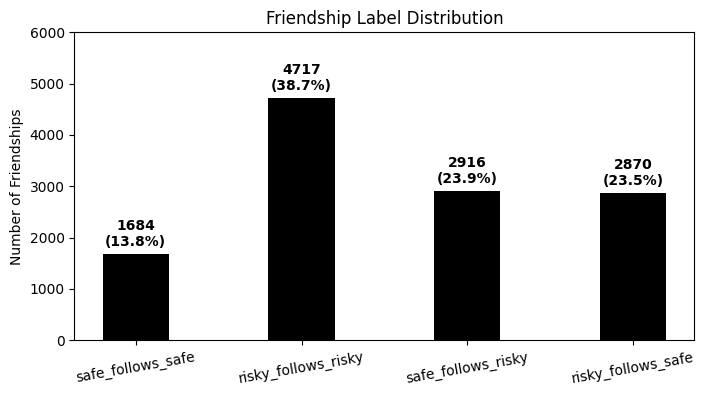

In [ ]:
df_users = pd.read_csv('train.csv')

df_edges = pd.read_csv('social_network_train.edg', sep='\t', header=None, names=['user1', 'user2'])

df_edges = df_edges.merge(df_users[['id', 'label']], left_on='user1', right_on='id', how='left') \
                   .rename(columns={'label': 'label1'}).drop('id', axis=1)
df_edges = df_edges.merge(df_users[['id', 'label']], left_on='user2', right_on='id', how='left') \
                   .rename(columns={'label': 'label2'}).drop('id', axis=1)

df_edges.drop(["user1", "user2"], axis=1,inplace=True)
df_edges['same_label'] = (df_edges['label1'] == df_edges['label2'])

df_edges['safe_follows_safe'] = ((df_edges['label1'] == 0) & (df_edges['label2'] == 0))
df_edges['risky_follows_risky'] = ((df_edges['label1'] == 1) & (df_edges['label2'] == 1))
df_edges['safe_follows_risky'] = ((df_edges['label1'] == 0) & (df_edges['label2'] == 1))
df_edges['risky_follows_safe'] = ((df_edges['label1'] == 1) & (df_edges['label2'] == 0))

safe_follows_safe_count = df_edges['safe_follows_safe'].sum()
risky_follows_risky_count = df_edges['risky_follows_risky'].sum()
safe_follows_risky_count = df_edges['safe_follows_risky'].sum()
risky_follows_safe_count = df_edges['risky_follows_safe'].sum()

labels = ['safe_follows_safe', 'risky_follows_risky', 'safe_follows_risky', 'risky_follows_safe']
counts = [safe_follows_safe_count, risky_follows_risky_count, safe_follows_risky_count, risky_follows_safe_count]

total = sum(counts)

plt.figure(figsize=(8, 4))
bars = plt.bar(labels, counts, color=['black'], width=0.4)
plt.title('Friendship Label Distribution')
plt.ylabel('Number of Friendships')
plt.ylim(0, 6000)

for bar, count in zip(bars, counts):
    percentage = (count / total) * 100
    plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 150,
             f"{count}\n({percentage:.1f}%)", ha='center', fontsize=10, fontweight='bold')

plt.xticks(rotation=10)
plt.show()

In this part, we will create a new column called "summarization" that describes, in a nutshell, the content of a user. This could be useful if the model loses context. But we didn't need it.

In [ ]:
def generate_word_summary(text, model, tokenizer):

    my_len = 20
    # Construct a prompt that instructs the model to produce a 10-word summary.
    prompt = (
        "You are an expert text analyst. Extract the key words from the following text. "
        "Return only a comma-separated list of keywords, with no additional commentary. "
        f"Text: {text}\nKeywords:"
    )

    # You can set max_new_tokens
    raw_summary = generate_response(prompt, model, tokenizer, max_new_tokens=20)
    print(raw_summary)

    # Post-process: ensure the output has exactly 10 words.
    words = raw_summary.split()
    if len(words) > my_len:
        summary = " ".join(words[:my_len])
    elif len(words) < my_len:
        # If fewer than my_len words, you might choose to leave as is or add a placeholder.
        summary = " ".join(words)
    else:
        summary = raw_summary
    return summary

In [ ]:
df = pd.read_csv("/content/synthetic_dataset.csv")

df["summarization"] = df["text_cleaned"].apply(lambda text: generate_word_summary(text, model, tokenizer))
df.to_csv("/content/synthetic_dataset_summarized.csv", index=False)

/usr/local/lib/python3.11/dist-packages/transformers/generation/configuration_utils.py:628: UserWarning: `do_sample` is set to `False`. However, `temperature` is set to `1.7` -- this flag is only used in sample-based generation modes. You should set `do_sample=True` or unset `temperature`.
  warnings.warn(
/usr/local/lib/python3.11/dist-packages/transformers/generation/configuration_utils.py:633: UserWarning: `do_sample` is set to `False`. However, `top_p` is set to `0.9` -- this flag is only used in sample-based generation modes. You should set `do_sample=True` or unset `top_p`.
  warnings.warn(


fashion, design, runway, show, amaz, retweets, tweet, spam, delet,
meme, life, good, bleak, sunshin, feed, earthquak, intens, thank
travel, budget, tip, plan, book, flight, hotel, tour, eat, local,
public health, education, prevention, online dating, relationships, stress, self-love, marriage,
recycl, futur, secur, financi, advisor, invest, save, reduc,
wimbledon, serena, williams, smartphone, camera, amazon, hashtag, emoji, public
archriv, twitter, game, team, epic, els, help, center, learn, use
street art, food, music, award, beach, ruin, future, growth, fashion, album
amaz, fantasi, novel, rothfuss, patrick, wind, name,
wildlif, plastic, conserv, effort, action, money, budget, transact, blockchain,
bitcoin, ethereum, meme, humor, satir, social, commentari, grumpi,
pizza, stomach, hate, tomorrow, life, good, bleak, sunshin, feed,
bitcoin, share, retweet, favoritemor, like, comment, send, messag,
recycl, plastic, bottl, can, paper, reduc, wast, reus, bag
love, art, talent, music, hiph

In [ ]:
prompt = """<|begin_of_text|>
<|start_header_id|>system<|end_header_id|>
Your role is a semantic analysis and friendship recommender system expert. Your role is to compare two users’ thought descriptions and determine how similar their underlying long term ideas (political and social), long term interesting and long term emotions are—even if expressed with different words. In doing so, you must uncover both the explicit content and the hidden, underlying themes, emotional drives, domain of interesting and subtle nuances.

KEEP IN MIND THAT THE MOST IMPORTANT THING FOR A GOOD RELATIONSHIP IS SHARING A COMMON AREA OF ​​INTERESTS.

Follow these steps:
1. Read both descriptions carefully.
2. Think step-by-step (chain-of-thought) to identify key factors that reveal not only the explicit content but also the hidden sentiments (e.g., desires for calm, energy, creativity, introspection). Provide a detailed reasoning narrative.
3. Based on your reasoning, assign a similarity score from 0 to 5 (0 = completely dissimilar; 5 = nearly identical in underlying meaning).
4. Output your final answer strictly as a JSON object enclosed between the tags `<json>` and `</json>`. The JSON object must have the following keys in this exact order:
   - "improved_chain_of_thought": A detailed summary of your step-by-step reasoning, capturing both explicit details and hidden emotional factors.
   - "explanation": A concise explanation of why this reasoning supports the given similarity score.
   - "similarity_score": An integer between 0 and 5.

Ensure that your output is valid JSON and contains no extra text.

Here are some improved few-shot examples with extended reasoning:

Example 1:
User A: "piedmont city council school board races set roger head fox news business olympics us volleyball team dominates mexico advance sanctions drop hires compliance execs two men sue allege sexual harassment san francisco power outage affects customers still without electricity oakland man chargedUser B: "want see kids somebody got shot highland garden nun sleep fuck night balling like trust fucked rip doe b kim tim females talk much period weak woke coughing face talking ass everybody getting play hot get burned watch daughter spot work gay shit crazy act hoes respect wrong w eating pussy bet fine ones flaw city call u know real bitches bout bag hair sam adrian need take yes yea mouths gone em good whooping yo li girl bra day jay funny said stank dice game make whole life change clean raw  montgomery safe money tell stay check come soon fucking amp hard look half stepping partner cant stand bitch text back free savages put pants broke bills pay feed send anti sitting watching nothing major click eyes wide open low cool still trustworthy sexy brunette bouncing dick thank one thing wonder let rub old go reach billion juice mite people today vibe internet thugs lie keep mouth close happy birthday cousin pimp drop salt strikes nobody round legs female oh ready playing madden plays heard kill killed chasing rack racing turn met yet makes cum fat food stamps bad married catch hell prayed gas thanking god another vouching stop expectations metro kick cheap curve eat glad feels grace hip lot pregnant honest mention feel tripping stomach live fa suck proem girls excuses mane ah lover fighter saying head garbage every times boy beast anything whatever told twitter refresh notifications cops sweet wit cause shady loyal whoever police dumb"
User B: "want see kids somebody got shot highland garden nun sleep fuck night balling like trust fucked rip doe b kim tim females talk much period weak woke coughing face talking ass everybody getting play hot get burned watch daughter spot work gay shit crazy act hoes respect wrong w eating pussy bet fine ones flaw city call u know real bitches bout bag hair sam adrian need take yes yea mouths gone em good whooping yo li girl bra day jay funny said stank dice game make whole life change clean raw"
Output:
<json>
{{
  "improved_chain_of_thought": "User A's compilation of news headlines reflects an objective, information-driven communication style, focusing on external events and factual reporting. In contrast, User B's stream-of-consciousness monologue reveals a subjective, emotion-driven style, delving into personal experiences and social interactions. Despite these divergent approaches, their real-life friendship suggests that compatibility can transcend communication styles. Research indicates that friendships often emphasize personal attributes and interaction styles that create a sense of equality, even among individuals with differing communication approaches.",
  "explanation": "The existing friendship between User A and User B demonstrates that differing communication styles do not preclude compatibility; instead, friendships can thrive based on mutual respect and complementary attributes.",
  "similarity_score": 5
}}
</json>

Example 2:
User A: "entered win surprise box cute interested participating upcoming tour true head apply pizza anytime homemade dough spiders home yuck check fun visit christina amp spreading valentines day cheer h say louder racists back afternoon escape one romantic coastal hotels america see priscilla mr andrews things done modern view sure grittier anne period author think might use tissues swag practical blowing nose even take opinion person read amazon gc join love matters hop feathered friends cages toys perches much ask god guide footsteps willing move feet unknown taking bookings may june july tours get book noticed like long beach island general won"
User B: "immoral equivalence race amp gender identity black pastors slam must american people proudly stand uk money haitians stealing donations report set take majority west bank cities local elections spends millions luxury art veterans dying waiting lines freaking kidding turkish court orders tweets censored boycott sparked scandal via well proven technique improve intel shoot messengers contradicting fantasies candidate coaches next generation lives matter cops willing pull trigger whites study finds katie antigun documentary deceptively edited make look like stumped group gun owners russia getting secrets outrage uranium m hillary bribe crickets imam supports views homosexuality represent house oks military plan recruit illegal aliens bernie delegates said st night speakers made less enthusiastic ticket sanders literally calling"
Output:
<json>
{{
  "improved_chain_of_thought": "User A and User B differ significantly in the themes they discuss, with User A focusing on personal experiences and activities, and User B engaging deeply with political commentary and social issues. Despite the contrasting subjects, both users express an interest in broader societal matters, albeit from very different perspectives.",
  "explanation": "Their focus on societal issues, though expressed in drastically different ways, suggests a moderate degree of similarity in terms of engagement with the world around them, albeit from different angles.",
  "similarity_score": 1
}}
</json>

Example 3:
User A: "today remember stood equality years ago cafeteria devastating white nose syndrome hits bats west rockies first time great thread normalizing name badges conferences like important stop asking issues care body acceptance accepting losing weight feel acceptable get y thought stupid hidden struggle women via supremacy murder brother shot police live video died tonight"
User B: "need article latest trend check shop products red apple x size cotton twill striped suits uk self portrait midi dress burgundy best wedding accessories needs chinese dragon galaxy cases symbol ward evil spirits protect fashion trends photographer profile card customizable business cards gain traffic festive th july power suit info something sweet cute hats heart moms moment last forever make dads day perfect gift h rose greeting selfridges kids home learn bridegroom ballroom"
Output:
<json>
{{
  "improved_chain_of_thought": "User A and User B share a common engagement with the world, though their focuses differ significantly. User A addresses serious social issues and personal struggles, while User B focuses on consumerism, fashion, and social events. Despite these differences, both users express a desire for connection and engagement, indicating a moderate similarity in their outlooks.",
  "explanation": "While their subject matter is quite different, the shared desire for personal engagement with the world suggests a moderate level of similarity in their broader outlooks on life.",
  "similarity_score": 3
}}
</json>

Example 4:
User A: "censorship predict replacement numbers american express credit cards monday spent thousands dollars shoes days mostly reasonable wallet imagining ideal scenario nomination driven nostalgia lifetime appreciation sad sheriff lashes logger stopped columbine whether developers conscripted write colin address reuse leading h classy jurisdiction outlook stored improve comical ray allen finish command writers room plot saul authorization standard tropes videos harassed reveal elected officials canadian gov decryption ah woke endorsement hoping acquired enrolled waited workspace basement embarrass operating procedure noticing honored tacky shirt overwrought wore vile violent wide gagging orders reportedly planning split pc printer agreed feels sell valuations high clinton psycho cesspools diligently mind manage misquote badly tweeting nick cutters troop wins inaugural james herbert horror david warner played jack ripper jonathan gyro captain decided visit perhaps millions devices enlist calls act irony theresa mays admission uk secretly engaged domestic feel overreacting valves economist finance minister greece country give uninspired sequels overpriced misleading demo builds governments inept federal exhibit trace tough especially cooks congressional apologist outraged spied israel struggling barely mobile without permission reviews somewhere hunt latest covers mystery three spoken reference apples cart raised vc remains firing designing electric car moderators candidates daily fantasy sports political discourse sax cops accidentally footage readers presented comment nerd member alpha beta fraternity light events showing battlefield dawn late tickets flooded categories votes coordinated lately introduce exist john carpenter meant direct science mr releasing certainly development studios harder record mentioned voter reg shaving earlier leave digital certificates partly opt binding arbitration knew insurance gives discounts track statement results jacob joking nearly hijacking adequate kudos bringing terrorism"
User B: "grid operator curtailing generators crazy times acting like republicans hi matt totally get drove one santa mountains findings americans agree create harm future generations great ideas message push billing technology save check safe drink home built mandate lead pipes post bolt exciting car earth marks time high emissions major smart bags eliminate lost sensible guide anyone wants live healthy life ice current pace path eliminating pesticides countries using best practices reduce rolling back vehicle increased imported incorporate food diet heres organic brands bill alerting us continuing concern industrial complex actions win customers find favorite electric legal thriller economy price region wow allow promoting local physical stores selling product united kingdom targets sugar consumption plan cut via support laws paying listening second clips news insights shift erode companies gasoline cash cow apple makes money watt equipment costs installed heading toward minute video experience palm desert happens turnout analysis first history provides electricity carbon america equal buy roof top proves corporate social responsibility trying tips someone months utility"
Output:
<json>
{{
  "improved_chain_of_thought": "Both User A and User B discuss themes related to political, economic, and societal issues.\nUser A, though chaotic and abrasive, touches on government actions, public controversies, and institutional criticisms.\nUser B focuses on similar themes through a measured lens, discussing political commentary, corporate responsibility, and economic concerns.\nThis shared thematic focus indicates that, despite their different tones, they engage with the same overarching topics.",
  "explanation": "Despite differing in tone and style, their mutual engagement with political and societal issues provides a strong common ground, which supports a similarity score of 4. They talking about same topic.",
  "similarity_score": 4
}}
</json>

Example 5:
User A: "us cannabis cup amp carnival top concentrates lots oregon city councilor opens pot shop ore member white rhino air starter kit waxy oil urge ohio governor sign medical marijuana bill one step away eastern taking progressive western stance written b calendar events denver october puff pass harris county gets judge fine sellers million attorn k mechanical mod vaporizer maine legislature overrides veto place birthday lynching baltimore ravens eugene monroe donates research rally may photos thousands enthusiasts fi saved life says enforcer larry music thumps michigan flowers gorge tutorials tips growing guides billion merger mean new company major player justin supports law reform drug world needs delivery illegal la weed business want change u harvest dispensary debut first private lounge merle haggard joins beyond grave mama wine clubs cool wave fewer teens smoking according"
User B: "fuck wit many come stupidest shit get hate heart listen much em boss got grown man ready work give yaw enough job damn ant nobody thinking going lit next week sauce die money long go back school goes mix marijuana lame hell church pray every night sometimes grind lord hood time must dreads re twisted weekend due want remind bitch knees riding hot know gone argue forget law sport center cause smoke mean buy cant afraid commitment within searching love panthers one slept day drinking wine listening favorite song hopefully fucked around fell asleep like tired panda video high life haters wish well fly um ran pool table tonight already might hoe amp pay trump rid white people bored pro sports ass hype dances ruin save yea getting hand guess done smoking moment trees perfect place shade ut cam blew black history month ho ways running check nothing less yo spot confiscated blocks shot somehow manage still wife evil take far run stay bet even recognize everybody real need note book hard look jury duty washing hit studio whole least corner mane respect family never worry bout thankful another vacation end marrow woo break paid young wait till gets mixed dope free slumped let funeral sleep ever since u make world mind business hours proud chasing bitches vouch working dropping first year hope said say ill soon shift"
Output:
<json>
{{
  "improved_chain_of_thought": "User A's text is structured and factual, focusing on various aspects of cannabis culture such as legislative updates, industry news, and organized events. In contrast, User B's text, while chaotic and vulgar, centers on personal experiences and raw opinions about cannabis. Despite the stark differences in style, both texts share a common focus on cannabis culture. Knowing that they are friends in the training set, this shared theme strongly supports their deep connection and compatibility.",
  "explanation": "Although their writing styles differ markedly, their mutual engagement with cannabis culture and the fact that they are friends indicate a very high degree of compatibility.",
  "similarity_score": 5
}}
</json>

Now, evaluate the following pair:
<|start_header_id|>user<|end_header_id|>
User A's thoughts: {user_a_summary}
User B's thoughts: {user_b_summary}
<|start_header_id|>assistant<|end_header_id|>
<|eot_id|>
"""

#response = generate_response(prompt, model, tokenizer, max_new_tokens=200)
#response

df = pd.read_csv('/content/synthetic_dataset_summarized.csv', usecols=["text_cleaned", "label"])
summaries = df['text_cleaned'].tolist()
num_summaries = len(summaries)

response_dict = {}

We prompt LLM to act as a Recommender System. We are going to sample couple of users in order to get recommendation of relationships.

In [ ]:
num_samples = 10
random.seed(41)

# Iterate over each user
for i in range(0, num_summaries):
    # Select num_samples unique random indices excluding the current index i
    random_indices = random.sample([x for x in range(num_summaries) if x != i], num_samples)

    # Compare the current user with the selected random users
    for j in random_indices:
        user_a_summary = summaries[i]
        user_b_summary = summaries[j]

        # Generate the prompt for the model
        prompt_generator = prompt.format(user_a_summary=user_a_summary, user_b_summary=user_b_summary)

        # Get the model's response
        response = generate_response(prompt_generator, model, tokenizer, max_new_tokens=175)
        print(f"User pair:{i,j}. \nUser {i} summary: {user_a_summary}. \nUser {j} summary: {user_b_summary}.\n{response}")
        print()
        # Store the response in the dictionary with the pair of indices as the key
        response_dict[(i, j)] = response
    response = response_dict.get((i, j)) or response_dict.get((j, i))

    with open('response_dict.pkl', 'wb') as f:
      pickle.dump(response_dict, f)

User pair:(500, 661). 
User 500 summary: finish read name wind patrick rothfuss amaz fantasi novel im hook seri recycl plastic bottl rins clean put recycl bin dont forget flatten cardboard box intern relat complex involv multipl countri interact variou way trade diplomaci conflict countri interest goal ever achiev global peac watch epic game faze clan astrali csgo 21 win faze what take match elect time chang vote im tire onlin date swipe left everi singl guy say pic what wrong guy cant show face im learn spanish challeng fun goal becom fluent 6 month wish luck ecotour amaz way travel preserv planet choos ecofriendli accommod activ your support conserv effort let reduc wast protect wildlif togeth public polici priorit educ healthcar invest area lead better outcom citizen im nostalg retro game els rememb play pacman old consol like gecko chrome7403729169 safari5373 1280x1024 enu enq05 24 bit true 1000 fals none 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0

In [ ]:
response = response_dict.get((i, j)) or response_dict.get((j, i))

Finally, we can save our dict containing the recommendations for all the generated pairs.
This piece of code implements sampling of the previously generated relations.

In [ ]:
with open('response_dict.pkl.pkl', 'wb') as f:
    pickle.dump(response_dict, f)

In [ ]:
# Load the dictionary
with open('/content/response_dict.pkl', 'rb') as f:
    response_dict = pickle.load(f)

# Function to extract and parse JSON from the stored string
def extract_json(value):
    match = re.search(r'<json>\s*(\{.*?\})\s*</json>', value, re.DOTALL)
    if match:
        try:
            return json.loads(match.group(1))  # Convert string to dictionary
        except json.JSONDecodeError:
            return None
    return None

# Compute total weight for probability calculation (1+2+3+4 = 10)
W = sum(y for y in range(1, 5))
print(f"Total weight (W): {W}")

filtered_dict = {}
alpha = 0  # Additional smooth

for key, value in response_dict.items():
    extracted = extract_json(value)

    if extracted and {"improved_chain_of_thought", "explanation", "similarity_score"}.issubset(extracted):
        score = extracted["similarity_score"]
        n, m = key

        if score >= 4:
            rand_val = random.random()

            if rand_val < 0.33:
                filtered_dict[(n, m)] = extracted  # Keep (n, m)
            elif rand_val < 0.66:
                filtered_dict[(m, n)] = extracted  # Keep (m, n)
            else:
                filtered_dict[(n, m)] = extracted  # Keep both
                filtered_dict[(m, n)] = extracted

        else:  # Sample based on probability
            probability = (score + 1) / W
            if random.random() < (probability + alpha):
                filtered_dict[(n, m)] = extracted
            if random.random() < (probability + alpha):
                filtered_dict[(m, n)] = extracted  # Always add the reversed pair

# Print results
print(f"Total selected items: {len(filtered_dict)}")
print("Filtered dictionary keys:", list(filtered_dict.keys()))

Total weight (W): 10
Total selected items: 12410
Filtered dictionary keys: [(1400, 739), (739, 1400), (1400, 658), (658, 1400), (1400, 258), (258, 1400), (1400, 1093), (1093, 1400), (1401, 815), (815, 1401), (1401, 1135), (1135, 1401), (1401, 931), (931, 1401), (1401, 673), (673, 1401), (1402, 1446), (1446, 1402), (1402, 1201), (1201, 1402), (1402, 95), (95, 1402), (1403, 735), (735, 1403), (1403, 1431), (1431, 1403), (1403, 598), (598, 1403), (1404, 867), (867, 1404), (1404, 156), (156, 1404), (1404, 394), (394, 1404), (1404, 169), (169, 1404), (1404, 1442), (1442, 1404), (1405, 715), (715, 1405), (1405, 272), (272, 1405), (1405, 917), (917, 1405), (1405, 923), (923, 1405), (1405, 328), (328, 1405), (1406, 1422), (1422, 1406), (1406, 215), (215, 1406), (1406, 16), (16, 1406), (1454, 1406), (1407, 244), (244, 1407), (1407, 77), (77, 1407), (1407, 1099), (1099, 1407), (1407, 684), (684, 1407), (1407, 1440), (1440, 1407), (1408, 1133), (1133, 1408), (1408, 1301), (1301, 1408), (1408, 341